# **MODEL TESTING**

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =========================
# Configuración
# =========================
TEST_CSV = "../../../data/definitivos/splits/test.csv"
MODEL_DIR = "./models/distilroberta_topicclf"   # mismo OUTPUT_DIR del training
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
df = pd.read_csv(TEST_CSV)

if "text_input" not in df.columns:
    df["text_input"] = df["headline"].fillna("") + " " + df["summary"].fillna("")

if "label" not in df.columns:
    raise ValueError("No existe columna 'label' en test.csv.")

texts = df["text_input"].astype(str).tolist()
y_true = df["label"].astype(int).to_numpy()

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()

le_path = os.path.join(MODEL_DIR, "label_encoder.joblib")
le = joblib.load(le_path)
class_names = list(le.classes_)

In [6]:
all_preds = []

with torch.no_grad():
    for i in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[i:i+BATCH_SIZE]
        enc = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.append(preds)

y_pred = np.concatenate(all_preds, axis=0)

In [7]:
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n===== RESULTADOS TEST =====")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"F1 Weighted  : {f1_weighted:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


===== RESULTADOS TEST =====
Accuracy     : 0.8256
F1 Macro     : 0.7471
F1 Weighted  : 0.8248

===== CLASSIFICATION REPORT =====
                                                             precision    recall  f1-score   support

Business Growth and Cloud Infrastructure in the AI Industry     0.7913    0.8864    0.8361       308
              Financial and Market News and Corporate Sales     0.8770    0.8363    0.8562       452
                         Informal / Conversational Lenguaje     0.6923    0.6000    0.6429        30
                  Quantum Computing and Military Technology     0.6875    0.5500    0.6111        20
                                   Stock Market and Trading     0.8037    0.7748    0.7890       222

                                                   accuracy                         0.8256      1032
                                                  macro avg     0.7704    0.7295    0.7471      1032
                                               weighted avg 

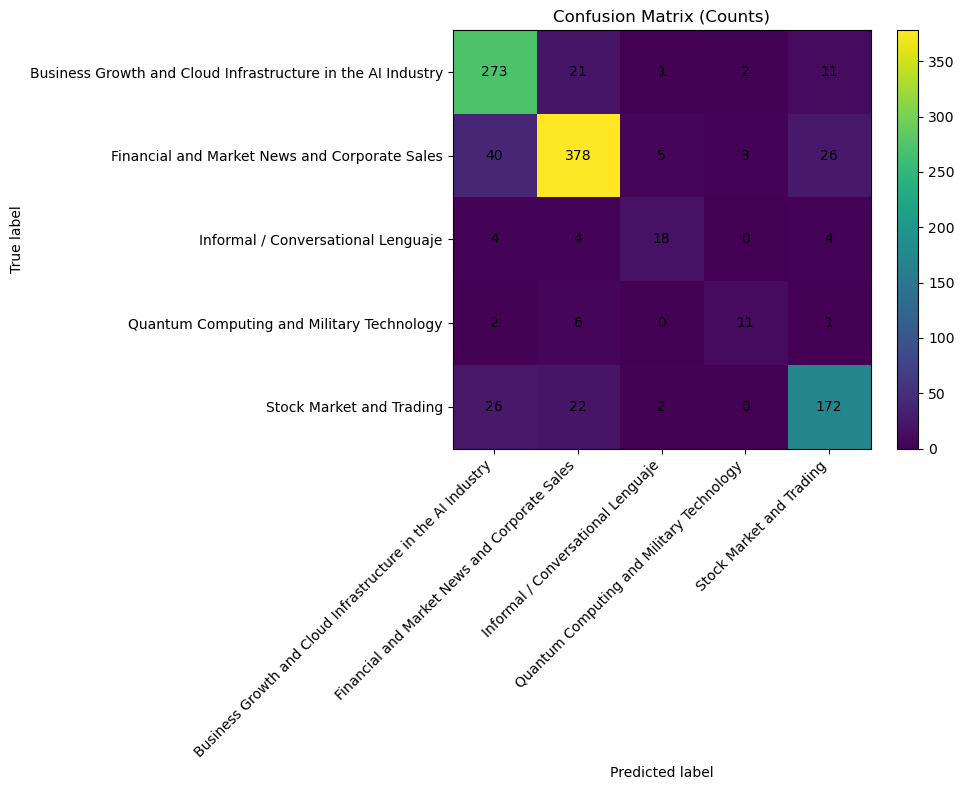

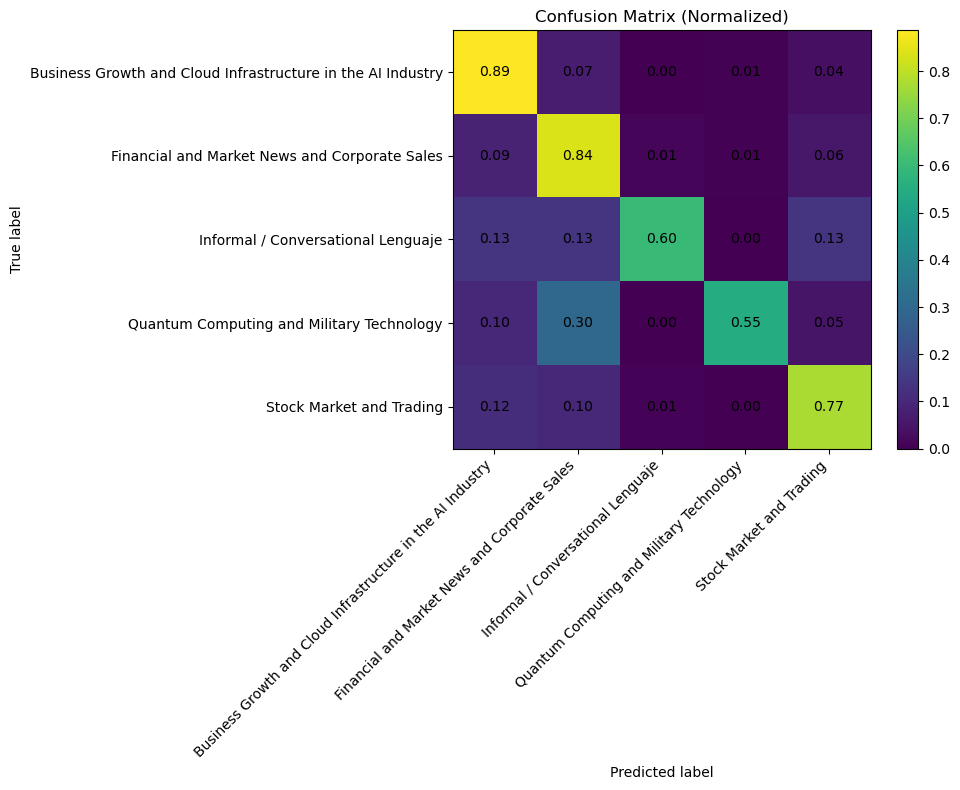

In [8]:
cm = confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, labels, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm_display = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
    else:
        cm_display = cm

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_display, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    # escribir valores en cada celda
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            val = cm_display[i, j]
            text = f"{val:.2f}" if normalize else str(int(val))
            plt.text(j, i, text, ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix (Counts)")
plot_confusion_matrix(cm, class_names, normalize=True, title="Confusion Matrix (Normalized)")

# **FINBERT**

In [12]:
import os
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =========================
# Configuración
# =========================
TEST_CSV = "../../../data/definitivos/splits/test.csv"
MODEL_DIR = "./models/finbert_topicclf"
BATCH_SIZE = 16
MAX_LEN = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [13]:
# =========================
# Utilidad: plot CM
# =========================
def plot_confusion_matrix(cm, labels, normalize=False, title="Confusion Matrix"):
    cm_show = cm.astype(float)
    if normalize:
        cm_show = cm_show / (cm_show.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_show, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)

    for i in range(cm_show.shape[0]):
        for j in range(cm_show.shape[1]):
            text = f"{cm_show[i, j]:.2f}" if normalize else str(int(cm[i, j]))
            plt.text(j, i, text, ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


# =========================
# 1) Cargar test.csv
# =========================
df = pd.read_csv(TEST_CSV)

# Por si acaso, reconstruimos text_input si no está
if "text_input" not in df.columns:
    df["text_input"] = df["headline"].fillna("") + " " + df["summary"].fillna("")

if "label" not in df.columns:
    raise ValueError("No existe columna 'label' en test.csv. Revisa el split.")

texts = df["text_input"].astype(str).tolist()
y_true = df["label"].astype(int).to_numpy()


# =========================
# 2) Cargar modelo + tokenizer
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()


# =========================
# 3) Cargar nombres de clase (si están)
# =========================
le_path = os.path.join(MODEL_DIR, "label_encoder.joblib")
if os.path.exists(le_path):
    le = joblib.load(le_path)
    class_names = list(le.classes_)
else:
    # fallback: clases numéricas
    n_classes = int(np.max(y_true)) + 1
    class_names = [str(i) for i in range(n_classes)]


In [14]:
# =========================
# 4) Predicción por batches
# =========================
all_preds = []

with torch.no_grad():
    for i in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[i:i + BATCH_SIZE]

        enc = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        )

        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.append(preds)

y_pred = np.concatenate(all_preds, axis=0)


===== RESULTADOS TEST (FinBERT) =====
Device      : cuda
Accuracy    : 0.8440
F1 Macro    : 0.7462
F1 Weighted : 0.8417

===== CLASSIFICATION REPORT =====
                                                             precision    recall  f1-score   support

Business Growth and Cloud Infrastructure in the AI Industry     0.8354    0.8896    0.8616       308
              Financial and Market News and Corporate Sales     0.8593    0.8783    0.8687       452
                         Informal / Conversational Lenguaje     0.6786    0.6333    0.6552        30
                  Quantum Computing and Military Technology     0.8000    0.4000    0.5333        20
                                   Stock Market and Trading     0.8480    0.7793    0.8122       222

                                                   accuracy                         0.8440      1032
                                                  macro avg     0.8043    0.7161    0.7462      1032
                                  

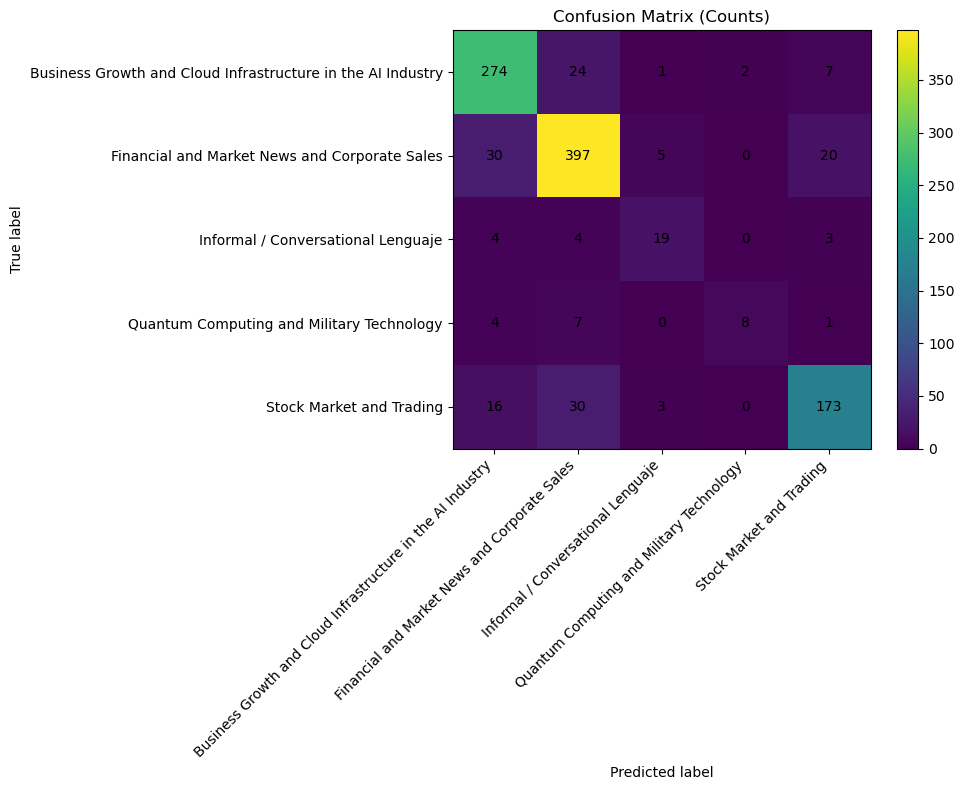

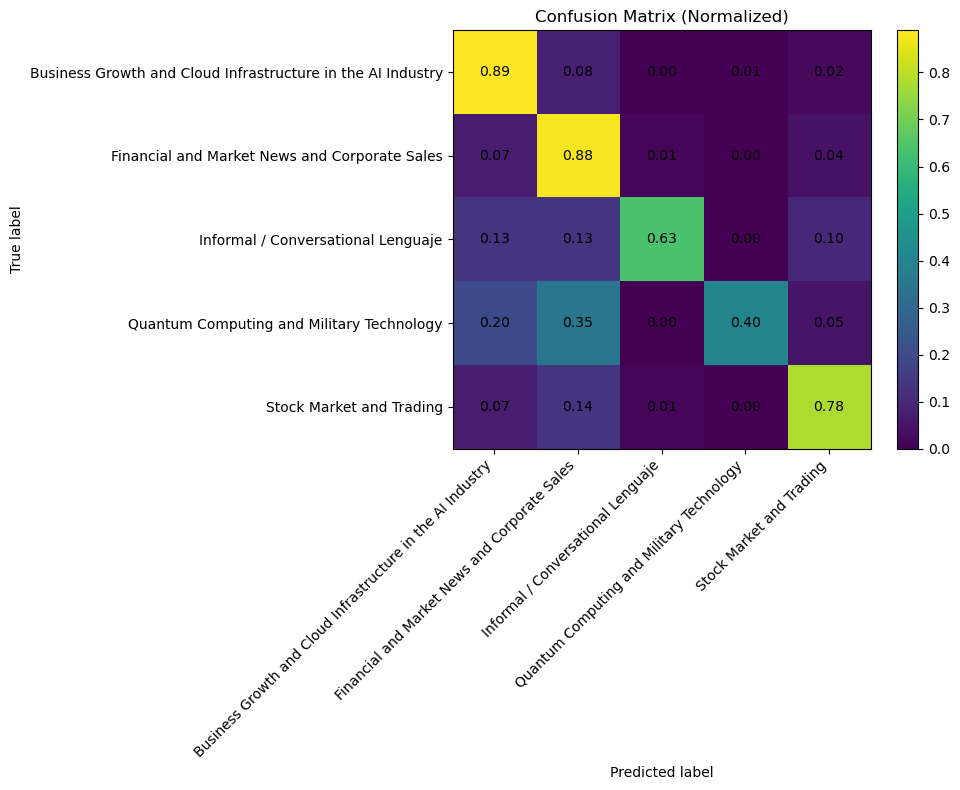

In [15]:
# =========================
# 5) Métricas + report
# =========================
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n===== RESULTADOS TEST (FinBERT) =====")
print(f"Device      : {DEVICE}")
print(f"Accuracy    : {acc:.4f}")
print(f"F1 Macro    : {f1_macro:.4f}")
print(f"F1 Weighted : {f1_weighted:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))


# =========================
# 6) Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix (Counts)")
plot_confusion_matrix(cm, class_names, normalize=True, title="Confusion Matrix (Normalized)")